In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
from sklearn.preprocessing import LabelEncoder
    

In [36]:
# load dataset
data = pd.read_csv('Asteroid.csv')
data.head()

    

C:\Users\HP\AppData\Local\Temp\ipykernel_21788\2587347652.py:2: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('Asteroid.csv')


,full_name,a,e,G,i,om,w,q,ad,per_y,...,rot_per,GM,BV,UB,IR,spec_B,spec_T,neo,pha,moid
0,136067 (2002 XK88),2.644842,0.344897,NaN,28.175594,348.629829,77.223507,1.732643,3.557040,4.301379,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,0.927588
1,(2014 EP239),3.208126,0.185009,NaN,16.124172,311.562427,220.800913,2.614594,3.801657,5.746259,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,1.644790
2,114427 (2003 AW2),2.669368,0.108137,NaN,32.898356,131.360969,312.712968,2.380710,2.958025,4.361349,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,1.450000
3,(2012 VU25),1.805945,0.094610,NaN,26.892233,38.030362,55.960288,1.635085,1.976805,2.426973,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,0.696145
4,(2007 RQ256),2.391237,0.205376,NaN,2.008390,50.430370,299.570604,1.900135,2.882338,3.697788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,N,0.894200


In [37]:
# Check for missing values
print("\nMissing Values:")
print(data.isnull().sum())



Missing Values:
full_name              0
a                      0
e                      0
G                  99990
i                      0
om                     0
w                      0
q                      0
ad                     1
per_y                  1
data_arc            1892
condition_code       122
n_obs_used             0
H                    294
diameter           83645
extent             99999
albedo             83803
rot_per            97784
GM                 99999
BV                 99888
UB                 99894
IR                100000
spec_B             99819
spec_T             99890
neo                    1
pha                 2045
moid                2045
dtype: int64


In [38]:
# Encode Categorical Columns
encoder= LabelEncoder()

for col in data.columns:
    if data[col].dtype == "object":
        data[col] = encoder.fit_transform(
            data[col].astype(str)
        )



In [39]:
# Select Target Column
target_column = "H"
target_column

'H'

In [40]:

# Features and Target
X = data.drop(columns=[target_column])
y = data[target_column]
X
y

0        14.500
1        18.172
2        15.200
3        20.200
4        18.457
          ...  
99995    15.800
99996    15.800
99997    15.900
99998    17.300
99999    17.192
Name: H, Length: 100000, dtype: float64

In [41]:
# Convert numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

y = pd.to_numeric(y, errors='coerce')
y = y.fillna(0)


In [42]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



In [43]:
# Base Model
base_model = DecisionTreeRegressor(
    max_depth=4
)
base_model

DecisionTreeRegressor(max_depth=4)

In [44]:

# AdaBoost Regressor
model = AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
model

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                  learning_rate=0.1, n_estimators=100, random_state=42)

In [45]:
#fit model
model.fit(X_train, y_train)


AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                  learning_rate=0.1, n_estimators=100, random_state=42)

In [46]:

#Prediction 
y_pred = model.predict(X_test)
y_pred


array([14.59452814, 17.09357374, 16.56196565, ..., 16.99043999,
       17.1876944 , 15.39459499], shape=(20000,))

In [47]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)


Model Evaluation
MAE : 0.8095917134519003
MSE : 1.676457891295146
RMSE : 1.2947810205958172
R2 Score : 0.604393749522436


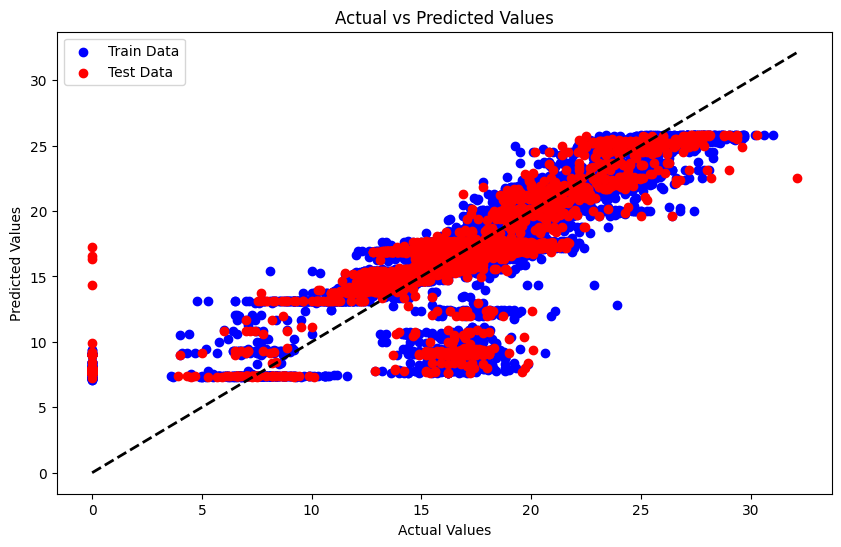

In [48]:
# train vs test
plt.figure(figsize=(10, 6))
plt.scatter(y_train, model.predict(X_train), color='blue', label='Train Data')
plt.scatter(y_test, y_pred, color='red', label='Test Data')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()
    